# DWBA diagnostics for a RuO$_2$/TiO$_2$ film

This notebook follows the atomistic distorted-wave Born approximation (DWBA)
construction in `doc/design/DWBA`.  It compares three versions of the example
RuO$_2$/TiO$_2$ film:

| system | surface | RuO$_2$/TiO$_2$ interface |
|---|---|---|
| A | flat (`mean_change = 0`) | flat (`width = 0`) |
| B | rough (one mean dissolved structural layer) | flat (`width = 0`) |
| C | rough (one mean dissolved structural layer) | rough (`width = 0.35` unit cells) |

The rough surface uses the signed Poisson dissolution already serialized in
`RuO2_TiO2_Poisson_etching.xtal`; the rough interface uses that file's
symmetric Skellam profile.  Only those two roughness parameters are varied, so
the TiO$_2$ substrate, RuO$_2$ film, energy, strain convention, and stacking
remain identical.

Angles passed to orGUI are glancing angles in radians.  Real-space distances
are in Angstrom and reciprocal coordinates are in reference-cell r.l.u.


In [1]:
%matplotlib inline
from pathlib import Path
import copy
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np


def _find_repository_root():
    '''Return the checkout containing this example notebook, if available.'''
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "orgui" / "datautils").is_dir():
            return candidate
    return None


repository_root = _find_repository_root()
if repository_root is not None and "orgui" not in sys.modules:
    sys.path.insert(0, str(repository_root))

from orgui.datautils.xrayutils import CTRcalc, CTRuc
from orgui.datautils.xrayutils.CTRoptics import (
    HC_KEV_ANGSTROM,
    homogeneous_bulk_profile,
)


def _find_example_file(filename):
    '''Find an example beside the notebook or from the repository root.'''
    candidates = [Path(filename), Path("examples/CTR") / filename]
    if repository_root is not None:
        candidates.append(repository_root / "examples" / "CTR" / filename)
    for candidate in candidates:
        if candidate.is_file():
            return candidate
    raise FileNotFoundError(filename)


if not hasattr(CTRcalc.SXRDCrystal, "dwba"):
    raise RuntimeError("The loaded orGUI build does not provide DWBA.")
if not hasattr(CTRuc._CTRcalc_cpp, "unitcell_F_DWBA_records"):
    raise RuntimeError(
        "Rebuild the native extension before running this notebook."
    )

plt.rcParams.update({"figure.dpi": 115, "axes.grid": True})


def _two_column_axes(panel_count, *, sharex=True, sharey=True, row_height=4.2):
    '''Create a Sphinx-friendly subplot grid with at most two columns.'''
    ncols = min(2, panel_count)
    nrows = int(np.ceil(panel_count / ncols))
    figure, axes = plt.subplots(
        nrows, ncols, figsize=(11.0, row_height * nrows),
        sharex=sharex, sharey=sharey, squeeze=False,
        constrained_layout=True,
    )
    return figure, axes.ravel()


## 1. The three structural systems

`PoissonSurface` expresses surface roughness as a coherent, signed correction
to the sharp film termination.  `EpitaxyInterface` uses complementary
upper/lower occupancies from a Skellam height distribution.  Zero width is the
sharp-interface limit; its signed lower-material records cancel rather than
adding a spurious layer.


In [2]:
model_path = _find_example_file("RuO2_TiO2_Poisson_etching.xtal")
model_template = CTRcalc.SXRDCrystal.fromFile(model_path)

ROUGH_SURFACE_MEAN = -1.0       # structural layers (negative = dissolution)
ROUGH_INTERFACE_WIDTH = 0.35   # unit cells


def _build_model(*, surface_mean, interface_width):
    '''Return one copied model with the requested roughness parameters.'''
    model = copy.deepcopy(model_template)

    surface = model["RuO2surface"]
    surface.profile = CTRcalc.PoissonProfile(
        mean_change=surface_mean,
        alpha=float(surface.basis[1]),
        offset=float(surface.basis[2]),
    )
    surface.basis[:] = (
        surface.profile.mean_change,
        surface.profile.alpha,
        surface.profile.offset,
    )

    interface = model["TiO2toRuO2"]
    interface.profile = CTRcalc.SkellamProfile(
        width=interface_width,
        asymmetry=float(interface.basis[1]),
    )
    interface.basis[0] = interface.profile.width
    interface.basis[1] = interface.profile.asymmetry

    model.apply_stacking()
    return model


systems = {
    "A — flat surface, flat interface": _build_model(
        surface_mean=0.0, interface_width=0.0
    ),
    "B — rough surface, flat interface": _build_model(
        surface_mean=ROUGH_SURFACE_MEAN, interface_width=0.0
    ),
    "C — rough surface, rough interface": _build_model(
        surface_mean=ROUGH_SURFACE_MEAN,
        interface_width=ROUGH_INTERFACE_WIDTH,
    ),
}

bulk_profile = homogeneous_bulk_profile(model_template.uc_bulk)
delta_bulk = float(bulk_profile.delta[0])
alpha_c = float(np.sqrt(2.0 * delta_bulk))

print(f"model: {model_path}")
print(f"energy: {model_template.uc_bulk._E * 1e-3:g} keV")
print(f"TiO2 bulk delta: {delta_bulk:.7g}")
print(f"alpha_c = sqrt(2 delta): {np.rad2deg(alpha_c):.5f} deg")
for label, model in systems.items():
    surface = model["RuO2surface"]
    interface = model["TiO2toRuO2"]
    print(
        f"{label}: surface mean = {surface.basis[0]:g} layers, "
        f"interface width = {interface.basis[0]:g} cells"
    )


model: RuO2_TiO2_Poisson_etching.xtal
energy: 20 keV
TiO2 bulk delta: 2.049891e-06
alpha_c = sqrt(2 delta): 0.11601 deg
A — flat surface, flat interface: surface mean = 0 layers, interface width = 0 cells
B — rough surface, flat interface: surface mean = -1 layers, interface width = 0 cells
C — rough surface, rough interface: surface mean = -1 layers, interface width = 0.35 cells


## 2. Matrix element and refractive-index contrast

The DWBA starting point is the contrast matrix element in electron units,

$$
F_\Delta=\int
\mathbf E_0(\mathbf r,-\mathbf k_f)\cdot
\mathbf E_0(\mathbf r,\mathbf k_i)\,
\Delta\rho_f(\mathbf r)\,d^3r.
$$

Here $\mathbf E_0(\mathbf r,\mathbf k)$ is the electric field in the layered
reference $n_0(z)$ for a unit-amplitude incoming plane wave with wavevector
$\mathbf k$, so $\mathbf k_i$ launches the incident field and $-\mathbf k_f$
launches the reciprocal field from the detector.
The reciprocal field is **not complex conjugated**; both fields are solved
in the same absorbing reference and already contain reflection, transmission,
and refraction.

We use $\mathbf Q=\mathbf k_f-\mathbf k_i$ and the Fourier factor
$e^{i\mathbf Q\cdot\mathbf r}$, with $z$ pointing out of the sample
(the substrate extends toward negative $z$).  Real-space coordinates are in
Angstrom and $\mathbf Q$ is in Angstrom$^{-1}$.

To express the density contrast in terms of the refractive index, define

$$
\gamma=\frac{2\pi r_e}{k_0^2},\qquad k_0=\frac{2\pi}{\lambda},
\qquad n(\mathbf r)\simeq1-\gamma\rho_f(\mathbf r),
$$

where $r_e$ is the classical electron radius and $\rho_f$ is the complex
scattering-factor density in electrons per Angstrom$^3$.  In each optical
medium $m$, the reference index and its density are constant:

$$
n_0(z)=1-\delta_m-i\beta_m,
\qquad \bar\rho_{f,m}=\frac{\delta_m+i\beta_m}{\gamma}.
$$

Thus the index contrast is explicitly

$$
\boxed{
\Delta n(\mathbf r)=n(\mathbf r)-n_0(z)
\simeq-\gamma\rho_f(\mathbf r)+\delta_m+i\beta_m
=-\gamma\Delta\rho_f(\mathbf r).
}
$$

Equivalently, the same matrix element is

$$
F_\Delta=-\frac{1}{\gamma}\int
\mathbf E_0(\mathbf r,-\mathbf k_f)\cdot
\mathbf E_0(\mathbf r,\mathbf k_i)\,
\Delta n(\mathbf r)\,d^3r,
$$

to first order in the X-ray refractive-index decrement.  This is the
atom-minus-reference subtraction used below.

The atomic $n(z)$ below is sampled from `SXRDCrystal.zDensity_G(z, 0, 0)`.
The reference $n_0(z)$ is the same thickness-conserving stratified profile
used to solve the DWBA wavefield.  Because $n$ differs from one by only a few
parts per million, the rendered plot shows the real decrement convention
$1-\operatorname{Re}n$ and $-\operatorname{Re}\Delta n$ on a linear vertical
axis.  Set `SHOW_IMAGINARY_INDEX = True` in the plotting cell to add panels
for $-\operatorname{Im}n$, $-\operatorname{Im}n_0$, and
$-\operatorname{Im}\Delta n$.


In [3]:
CLASSICAL_ELECTRON_RADIUS_ANGSTROM = 2.8179403262e-5
wavelength = HC_KEV_ANGSTROM / (model_template.uc_bulk._E * 1e-3)
index_density_scale = (
    CLASSICAL_ELECTRON_RADIUS_ANGSTROM * wavelength**2 / (2.0 * np.pi)
)

all_profiles = [model.optical_profile() for model in systems.values()]
z_min = -2.0 * float(model_template.uc_bulk.a[2])
z_max = max(profile[-1, 0] for profile in all_profiles) + float(
    model_template["RuO2"].unitcell.a[2]
)
z = np.linspace(z_min, z_max, 5000)


def _sample_index_decomposition(model, z_values):
    '''Sample atomistic n, layered n0, and their contrast on one z grid.'''
    rho_f = model.zDensity_G(z_values, 0.0, 0.0)
    n = 1.0 - index_density_scale * rho_f

    profile = model.stratified_optical_profile()
    medium = np.searchsorted(profile.boundaries, z_values, side="right")
    n0 = 1.0 - profile.delta[medium] - 1j * profile.beta[medium]
    delta_n = n - n0
    np.testing.assert_allclose(n, n0 + delta_n, rtol=0.0, atol=2e-22)
    return n, n0, delta_n


index_components = {
    label: _sample_index_decomposition(model, z)
    for label, model in systems.items()
}


Text(0.5, 0.98, 'Atomic index, layered reference, and contrast: $n=n_0+\\Delta n$')

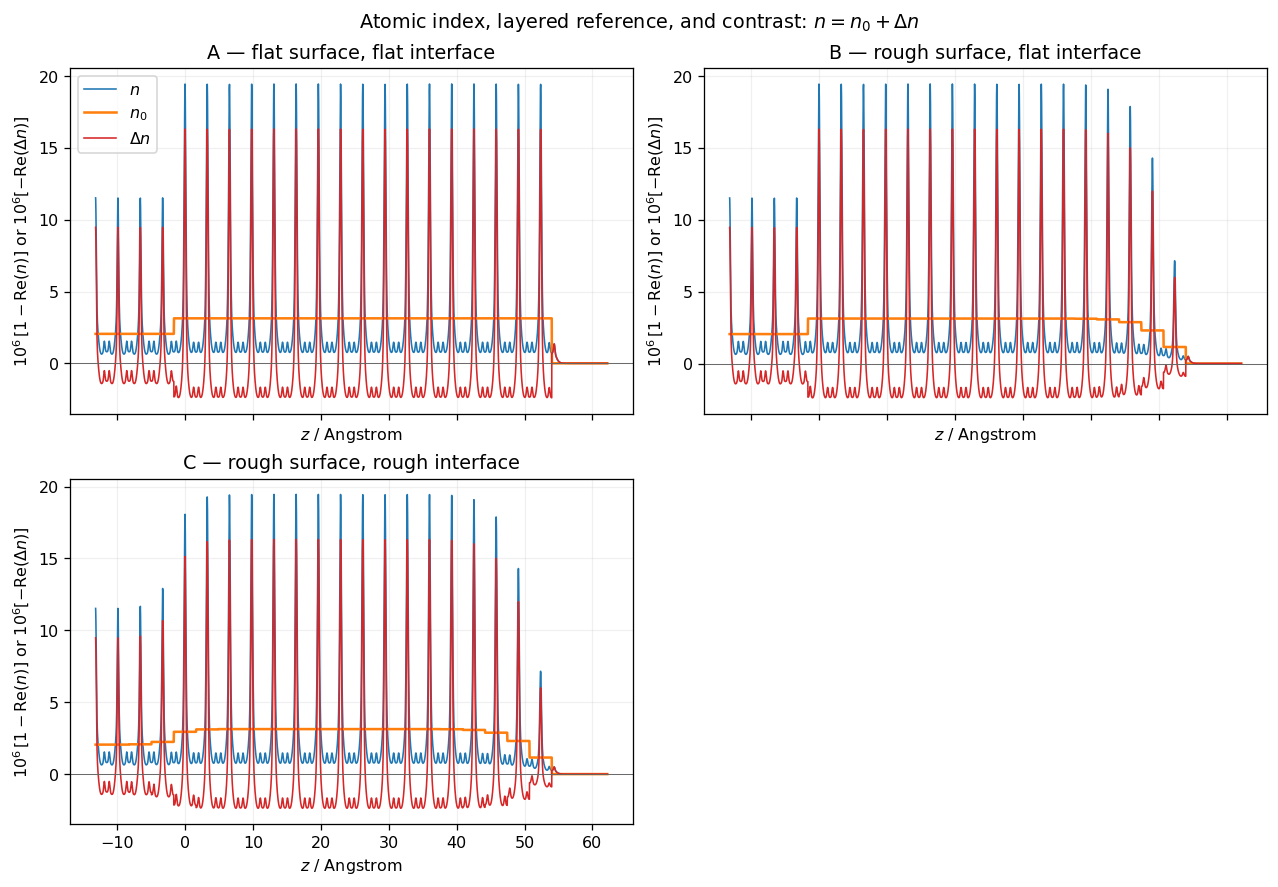

In [4]:
SHOW_IMAGINARY_INDEX = False

index_parts = [
    (
        "real",
        lambda values: 1e6 * (1.0 - values.real),
        lambda values: -1e6 * values.real,
        r"$10^6\,[1-\mathrm{Re}(n)]$ or $10^6[-\mathrm{Re}(\Delta n)]$",
    )
]
if SHOW_IMAGINARY_INDEX:
    index_parts.append(
        (
            "imaginary",
            lambda values: -1e8 * values.imag,
            lambda values: -1e8 * values.imag,
            r"$10^8\,[-\mathrm{Im}(n)]$ or $10^8[-\mathrm{Im}(\Delta n)]$",
        )
    )

index_panels = [
    (label, components, part)
    for part in index_parts
    for label, components in index_components.items()
]
figure, axes = _two_column_axes(
    len(index_panels), sharex=True, sharey=False, row_height=3.8
)
for axis, (label, (n, n0, delta_n), part) in zip(axes, index_panels):
    part_name, index_transform, contrast_transform, ylabel = part
    axis.plot(
        z, index_transform(n), color="C0", lw=1.0, label=r"$n$"
    )
    axis.plot(
        z, index_transform(n0), color="C1", lw=1.6, label=r"$n_0$"
    )
    axis.plot(
        z, contrast_transform(delta_n), color="C3", lw=1.0,
        label=r"$\Delta n$",
    )
    axis.set_title(label if not SHOW_IMAGINARY_INDEX else f"{label}\n{part_name} part")
    axis.set_xlabel(r"$z$ / Angstrom")
    axis.set_ylabel(ylabel)
    axis.axhline(0.0, color="0.4", lw=0.6)
    axis.grid(alpha=0.18)

for axis in axes[len(index_panels):]:
    axis.set_visible(False)
axes[0].legend(loc="upper left")
figure.suptitle(
    r"Atomic index, layered reference, and contrast: $n=n_0+\Delta n$"
)


## 3. From fields to channels and the specular observable

### Field amplitudes and four channels

Solving the wave equation for $n_0(z)$, with the interface boundary
conditions, gives the downward and upward field amplitudes
$A_{m,j}^{+}$ and $A_{m,j}^{-}$.  For the $s$ polarization used here,
they are the coefficients in the field expansion below; amplitudes,
atomic positions, and slab boundaries all use one common origin for $z$:

$$
\mathbf E_{0,j}(\mathbf r)=
\boldsymbol\epsilon_j e^{-i\boldsymbol\kappa_{j,\parallel}\cdot\mathbf r_\parallel}
\left(A_{m,j}^{+}e^{-ik_{z,m,j}z}
+A_{m,j}^{-}e^{+ik_{z,m,j}z}\right),\qquad j=i,f.
$$

Here $\mathbf E_{0,i}=\mathbf E_0(\mathbf r,\mathbf k_i)$ and
$\mathbf E_{0,f}=\mathbf E_0(\mathbf r,-\mathbf k_f)$, so
$\boldsymbol\kappa_{i,\parallel}=\mathbf k_{i,\parallel}$ and
$\boldsymbol\kappa_{f,\parallel}=-\mathbf k_{f,\parallel}$.
The $\boldsymbol\epsilon_j$ are the $s$ polarization vectors.  The Renaud
normal wavevectors obey $\operatorname{Re}k_z\leq0$ and
$\operatorname{Im}k_z\geq0$; $+$ labels the downward branch and $-$ the upward
branch.

Multiplying the two fields gives four coherent channels,
$\nu=(\sigma_i,\sigma_f)\in\{++,+-,-+,--\}$, with

$$
Q_{z,m}^{\nu}=-(\sigma_i k_{z,m,i}+\sigma_f k_{z,m,f}),
\qquad \mathbf Q_m^\nu=(\mathbf Q_\parallel,Q_{z,m}^\nu),
$$

$$
\mathcal C_m^\nu=A_{m,i}^{\sigma_i}A_{m,f}^{\sigma_f}P,
\qquad P=\boldsymbol\epsilon_f\cdot\boldsymbol\epsilon_i=\cos\varphi.
$$

$\varphi$ is the in-plane scattering angle, so $P=1$ on the specular rod.
For other polarizations the contraction is channel dependent.

### One simple unit cell

Take one unit cell of lateral area $A_{\rm ref}$, with no domain transforms
or extra model weights.  Its atomic channel amplitude is simply

$$
\boxed{
\mathcal A_m^\nu=\mathcal C_m^\nu
\sum_{a\in m}o_a f_a(\mathbf Q_m^\nu,E)
e^{i\mathbf Q_m^\nu\cdot\mathbf r_a}.
}
$$

The sum contains the cell's atoms in medium $m$; $o_a$ is occupancy and
$\mathbf r_a$ is the physical atomic position.  Here $f_a$ includes the
resonant atomic form factor and the Debye–Waller factor.  Both are evaluated
at the channel's complex momentum transfer, with
$Q^2=|\mathbf Q_\parallel|^2+(Q_{z,m}^\nu)^2$, without taking its modulus.
If the cell crosses an optical boundary, split its atoms between the media.
The full model adds the cells with their stacking, weights, domains, and
lateral-area normalization; the same channel construction applies to each.

$$
F_{\mathrm{atomic}}=\sum_m\sum_\nu\mathcal A_m^\nu.
$$

These are amplitudes: sum the four channels before taking a squared modulus.

### Index contrast and the slab depth integral

On the specular rod, $\mathbf Q_\parallel=0$.  Consider a finite optical slab
$z_m^-<z<z_m^+$ over one lateral reference cell.  The constant term
$\delta_m+i\beta_m$ in $\Delta n$ contributes throughout its thickness,
weighted by the channel phase.  Its depth integral is

$$
\Phi_m(q)=\int_{z_m^-}^{z_m^+}e^{iqz}\,dz
=\begin{cases}
\dfrac{e^{iqz_m^+}-e^{iqz_m^-}}{iq}, & q\ne0,\\[2mm]
z_m^+-z_m^-, & q=0.
\end{cases}
$$

$\Phi_m$ has units of Angstrom; at zero momentum transfer it is just the
slab thickness.  Inserting the explicit $\Delta n$ from section 2 gives its
slab Fourier integral (to the same first order in the index decrement):

$$
\widetilde{\Delta n}_m(q)
=\int_{\text{slab }m}\Delta n(\mathbf r)e^{iqz}\,d^3r,
$$

$$
\widetilde{\Delta n}_m(q)
=-\gamma\sum_{a\in m}o_a f_a((\mathbf 0,q),E)e^{iqz_a}
+A_{\rm ref}(\delta_m+i\beta_m)\Phi_m(q).
$$

Thus $\Phi_m$ enters the **integrated** index contrast through the constant
reference density.  Multiplying by the channel fields gives

$$
F_\Delta^{\mathrm{spec}}
=-\frac{1}{\gamma}\sum_m\sum_\nu
\mathcal C_m^\nu\widetilde{\Delta n}_m(Q_{z,m}^\nu)
=F_{\mathrm{atomic}}-F_{\mathrm{ref}},
$$

$$
F_{\mathrm{ref}}=\frac{A_{\rm ref}}{\gamma}
\sum_m(\delta_m+i\beta_m)
\sum_\nu\mathcal C_m^\nu\Phi_m(Q_{z,m}^\nu).
$$

For the terminal substrate replace the finite interval by
$(-\infty,z_m^+)$: $\Phi_m(q)=e^{iqz_m^+}/(iq)$ on the decaying branch
($\operatorname{Im}q<0$).  Only $++$ survives there because both upward field
amplitudes vanish; the repeated atomic cells use their semi-infinite lattice
sum.  Finite layers retain all four channels.

At a genuinely non-specular point the laterally infinite planar reference
has no Fourier component, so $F_{\mathrm{ref}}=0$ and
$F_\Delta^{\mathrm{nonsp}}=F_{\mathrm{atomic}}$.  The reference-cell area above
normalizes the specular amplitude; it does not turn the planar reference into
a finite lateral patch off specular.

### Reflectivity

For a specular semi-infinite calculation, orGUI returns the dimensionless
amplitudes

$$
\Delta r=-\frac{2\pi i r_e}{A_{\rm ref}k_{z,\mathrm{amb},f}}
F_\Delta^{\mathrm{spec}},
\qquad r_{\mathrm{total}}=r_0+\Delta r,
\qquad R_{\mathrm{coh}}=|r_{\mathrm{total}}|^2.
$$

Here $r_0$ is the reflection amplitude of $n_0(z)$ and
$k_{z,\mathrm{amb},f}=-k_0\sin\alpha_f$ in vacuum.  The plots display
$|r_0|^2$, $|\Delta r|^2$, and $|r_0+\Delta r|^2$, retaining the coherent sum.
For comparison, the kinematical structure factor is converted to the same
dimensionless field normalization,

$$
r_{\mathrm{kin}}=
\frac{2\pi i r_e}{k_0\sin\alpha_f\,A_{\rm ref}}F_{\mathrm{kin}}.
$$

These kinematical curves retain the model's serialized empirical attenuation.
They do not include the DWBA optical fields or polarization contraction, so
they are a diagnostic comparison rather than another decomposition of
$r_0+\Delta r$.


In [5]:
L_near = np.unique(
    np.concatenate(
        (
            np.geomspace(0.002, 0.25, 4800, endpoint=False),
            np.geomspace(0.25, 3.0, 1200),
        )
    )
)


def _structure_factor_to_field(F, prepared):
    '''Convert an electron-unit structure factor to field amplitude.'''
    return (
        2j * np.pi * CLASSICAL_ELECTRON_RADIUS_ANGSTROM * F
        / (
            prepared.k0 * np.sin(prepared.alpha_f)
            * prepared.reference_area
        )
    )


ANGLE_BATCH_SIZE = 30


def _batch_slices(size):
    '''Yield slices that fit within the DWBA unique-angle field cache.'''
    for start in range(0, size, ANGLE_BATCH_SIZE):
        yield slice(start, min(start + ANGLE_BATCH_SIZE, size))


def _evaluate_specular_l(model, L):
    '''Evaluate DWBA and kinematical specular amplitudes on one L grid.'''
    model.dwba.set_ctr_geometry(equal_angles=True, rods=[(0.0, 0.0)])
    amplitudes = {
        "r0": [], "delta_r": [], "total": [],
        "alpha_i": [], "r_kinematic": [],
    }
    for batch in _batch_slices(L.size):
        L_batch = L[batch]
        h = np.zeros_like(L_batch)
        k = np.zeros_like(L_batch)
        result = model.dwba.evaluate(
            h, k, L_batch, polarization_i="s", polarization_f="s"
        )
        amplitudes["r0"].append(result.unperturbed_amplitude)
        amplitudes["delta_r"].append(result.scattered_amplitude)
        amplitudes["total"].append(result.total_amplitude)
        amplitudes["alpha_i"].append(result.prepared.alpha_i)
        amplitudes["r_kinematic"].append(
            _structure_factor_to_field(
                model.F(h, k, L_batch), result.prepared
            )
        )
        np.testing.assert_allclose(
            result.total_amplitude,
            result.unperturbed_amplitude + result.scattered_amplitude,
        )
    return {
        name: np.concatenate(values) for name, values in amplitudes.items()
    }


near_critical = {
    label: _evaluate_specular_l(model, L_near)
    for label, model in systems.items()
}

Text(0.5, 0.98, 'Specular DWBA from the TiO$_2$ critical edge through $L=3$')

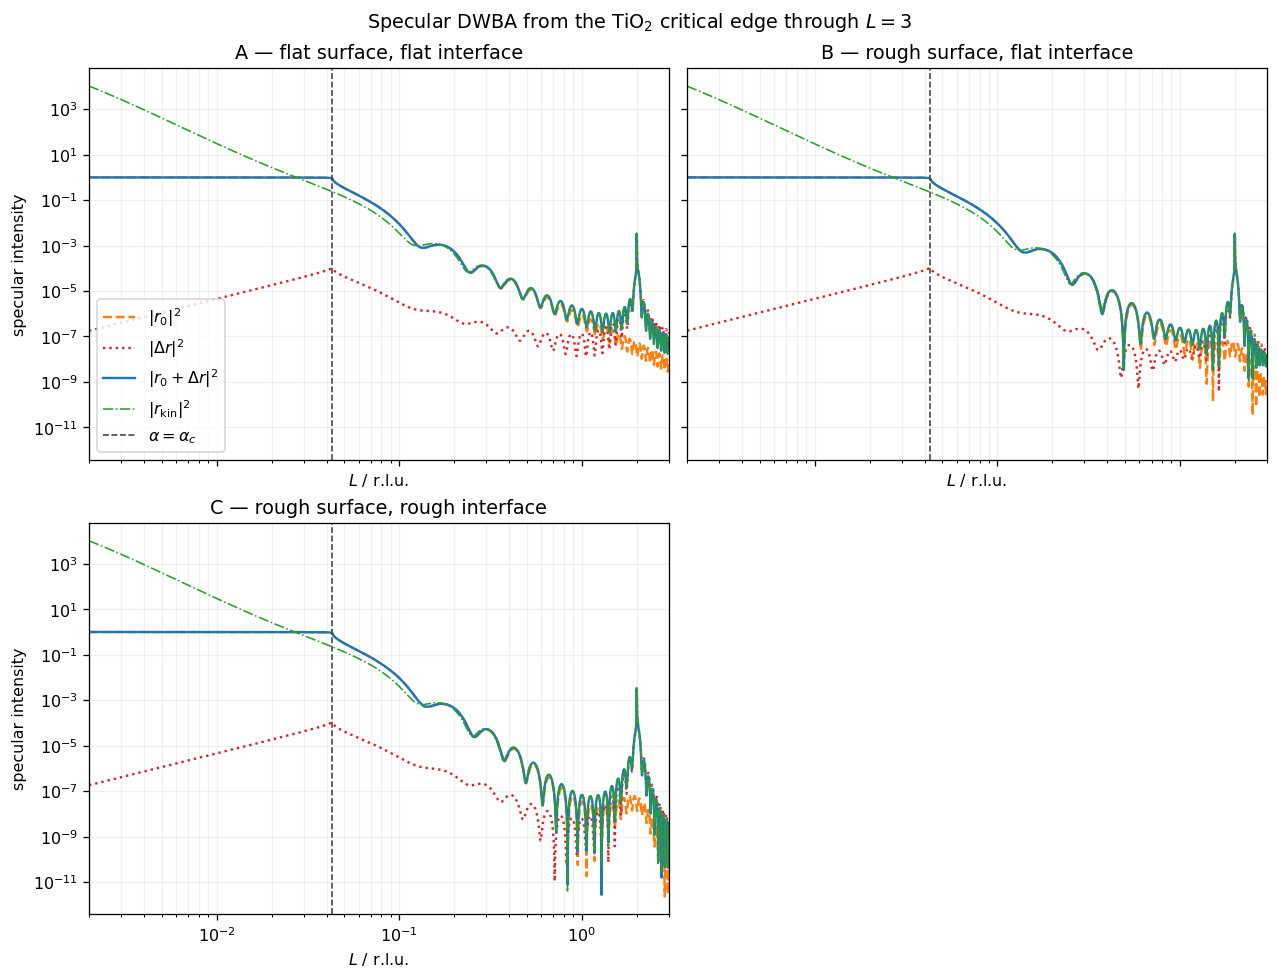

In [6]:
figure, axes = _two_column_axes(len(near_critical), row_height=4.2)
for axis, (label, diagnostic) in zip(axes, near_critical.items()):
    axis.loglog(
        L_near,
        np.abs(diagnostic["r0"]) ** 2,
        "--", color="C1", label=r"$|r_0|^2$",
    )
    axis.loglog(
        L_near,
        np.abs(diagnostic["delta_r"]) ** 2,
        ":", color="C3", label=r"$|\Delta r|^2$",
    )
    axis.loglog(
        L_near,
        np.abs(diagnostic["total"]) ** 2,
        "-", color="C0", label=r"$|r_0+\Delta r|^2$",
    )
    axis.loglog(
        L_near,
        np.abs(diagnostic["r_kinematic"]) ** 2,
        "-.", color="C2", lw=1.0, label=r"$|r_{\mathrm{kin}}|^2$",
    )
    critical_index = np.argmin(np.abs(diagnostic["alpha_i"] - alpha_c))
    axis.axvline(
        L_near[critical_index], color="0.25", ls="--", lw=1.0,
        label=r"$\alpha=\alpha_c$",
    )
    axis.set_title(label)
    axis.set_xlabel(r"$L$ / r.l.u.")
    axis.set_xlim(L_near[0], 3.0)
    axis.grid(alpha=0.18, which="both")

for axis in axes[len(near_critical):]:
    axis.set_visible(False)
for axis in axes[:len(near_critical):2]:
    axis.set_ylabel("specular intensity")
axes[0].legend(loc="lower left")
figure.suptitle(
    r"Specular DWBA from the TiO$_2$ critical edge through $L=3$"
)

## 4. Extended specular $(0,0,L)$ rod

At equal incident and exit angles the specular reflectivity and the
$(0,0,L)$ CTR are the same observable, simply parameterized by different
coordinates.  The logarithmic plot above resolves the critical edge and
continues through $L=3$; the linear-$L$ scan below extends the comparison to
$L=5$.  The low-$L$ cutoff avoids the singular normalization exactly at zero
exit angle; the displayed axis still starts at zero.

In [7]:
L_specular = np.linspace(0.002, 5.0, 2600)


specular_ctr = {
    label: _evaluate_specular_l(model, L_specular)
    for label, model in systems.items()
}

Text(0.5, 0.98, 'Extended specular $(0,0,L)$ DWBA')

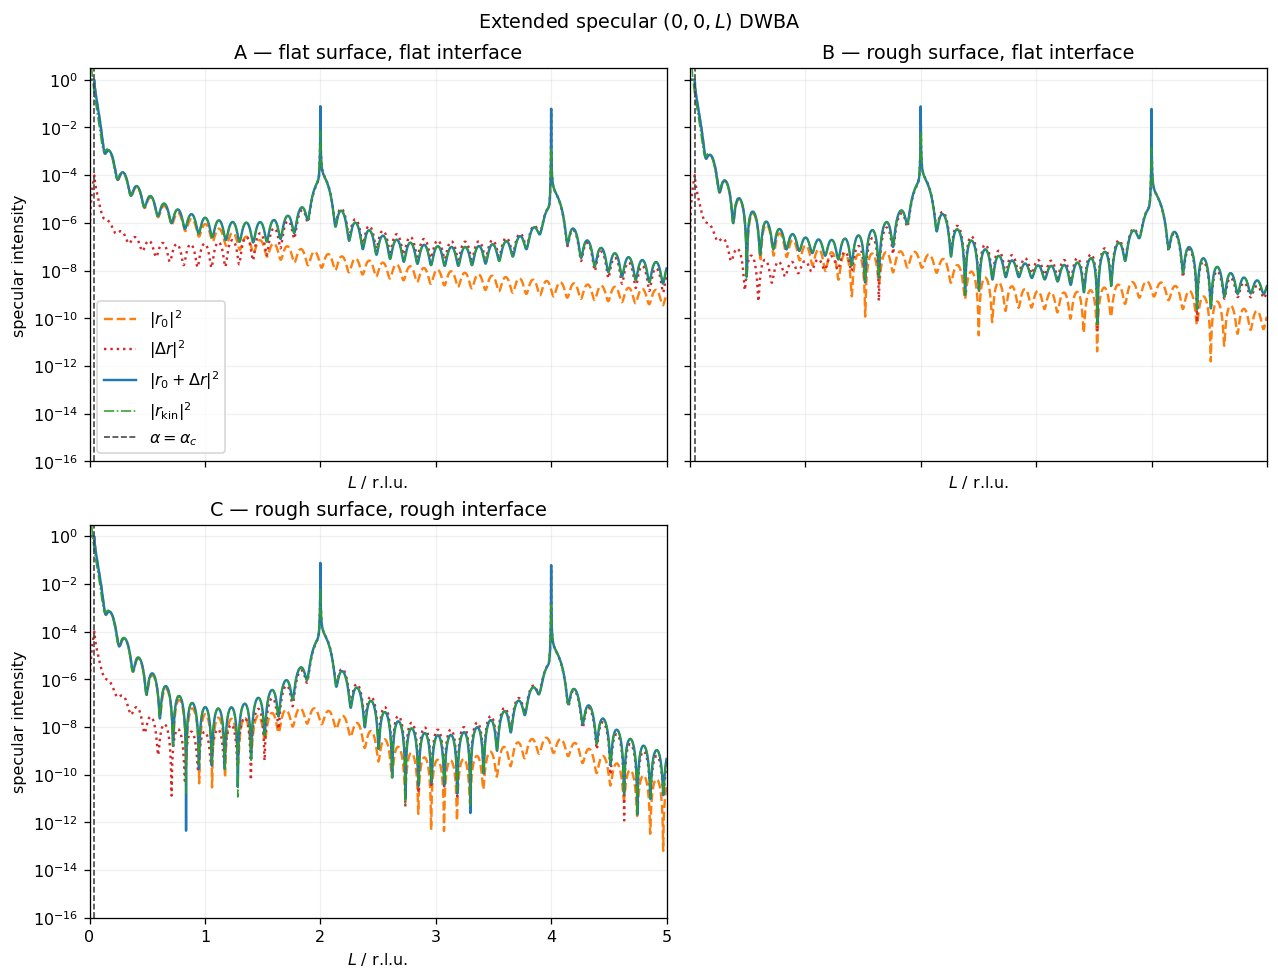

In [8]:
figure, axes = _two_column_axes(len(specular_ctr), row_height=4.2)
for axis, (label, diagnostic) in zip(axes, specular_ctr.items()):
    axis.semilogy(
        L_specular, np.abs(diagnostic["r0"]) ** 2,
        "--", color="C1", label=r"$|r_0|^2$",
    )
    axis.semilogy(
        L_specular, np.abs(diagnostic["delta_r"]) ** 2,
        ":", color="C3", label=r"$|\Delta r|^2$",
    )
    axis.semilogy(
        L_specular, np.abs(diagnostic["total"]) ** 2,
        "-", color="C0", label=r"$|r_0+\Delta r|^2$",
    )
    axis.semilogy(
        L_specular, np.abs(diagnostic["r_kinematic"]) ** 2,
        "-.", color="C2", lw=1.0, label=r"$|r_{\mathrm{kin}}|^2$",
    )
    critical_index = np.argmin(np.abs(diagnostic["alpha_i"] - alpha_c))
    axis.axvline(
        L_specular[critical_index], color="0.25", ls="--", lw=1.0,
        label=r"$\alpha=\alpha_c$",
    )
    axis.set_title(label)
    axis.set_xlabel(r"$L$ / r.l.u.")
    axis.set_xlim(0.0, 5.0)
    axis.set_ylim(1e-16, 3.0)
    axis.grid(alpha=0.18, which="both")

for axis in axes[len(specular_ctr):]:
    axis.set_visible(False)
for axis in axes[:len(specular_ctr):2]:
    axis.set_ylabel("specular intensity")
axes[0].legend(loc="lower left")
figure.suptitle(r"Extended specular $(0,0,L)$ DWBA")

## 5. Non-specular $(1,1,L)$ rod at two incident angles

For a genuine non-specular point the laterally homogeneous reference has no
Fourier component.  Thus $F_{\mathrm{ref}}=0$, $r_0=0$, and
$r_{\mathrm{total}}=\Delta r$.  Reflectivity is reserved for the specular
channel, so the appropriate off-specular observable plotted here is the
per-reference-cell differential cross-section kernel

$$
\left(\frac{d\sigma}{d\Omega}\right)_{\mathrm{cell}}
=r_e^2\left|F_\Delta^{\mathrm{nonsp}}\right|^2.
$$

It excludes footprint, coherence, detector acceptance, resolution, flux,
exposure, and efficiency.  The kinematical comparison is
$r_e^2|F_{\mathrm{kin}}|^2$ with the model's serialized empirical
attenuation; it has no distorted fields or polarization contraction.  Both curves use fixed-incidence z-mode geometry,
with $\alpha_i=0.5\alpha_c$ and $1.5\alpha_c$.  Sampling positive exit angles
and deriving $L$ avoids asking for geometrically inaccessible low-$L$ points.


In [9]:
incident_factors = (0.5, 1.5)
alpha_f_scan = np.linspace(np.deg2rad(0.002), np.deg2rad(35.0), 3600)


def _evaluate_non_specular_ctr(model, alpha_i_factor):
    '''Evaluate the accessible (1, 1, L) rod at fixed incidence.'''
    alpha_i = alpha_i_factor * alpha_c
    L_batches = []
    dwba_batches = []
    for batch in _batch_slices(alpha_f_scan.size):
        result = model.dwba.evaluate_from_glancing(
            1.0, 1.0, alpha_i, alpha_f_scan[batch],
            polarization_i="s", polarization_f="s",
        )
        L_batch = np.asarray(result.prepared.hkl[2], dtype=np.float64)
        selected = (L_batch >= 0.0) & (L_batch <= 5.0)
        L_batches.append(L_batch[selected])
        dwba_batches.append(
            np.asarray(result.differential_cross_section_kernel)[selected]
        )
        np.testing.assert_array_equal(result.unperturbed_amplitude, 0.0j)
        np.testing.assert_allclose(result.F_reference, 0.0j, atol=0.0)
        np.testing.assert_allclose(
            result.total_amplitude, result.scattered_amplitude
        )
    L = np.concatenate(L_batches)
    dwba = np.concatenate(dwba_batches)
    if L.size < 10:
        raise RuntimeError("The exit-angle scan did not cover 0 <= L <= 5.")
    F_kinematic = model.F(
        np.ones_like(L), np.ones_like(L), L
    )
    return {
        "L": L,
        "dwba": dwba,
        "kinematic": (
            CLASSICAL_ELECTRON_RADIUS_ANGSTROM**2
            * np.abs(F_kinematic) ** 2
        ),
    }


non_specular_ctr = {
    label: {
        factor: _evaluate_non_specular_ctr(model, factor)
        for factor in incident_factors
    }
    for label, model in systems.items()
}

Text(0.5, 0.98, 'Non-specular $(1,1,L)$ DWBA at fixed incidence')

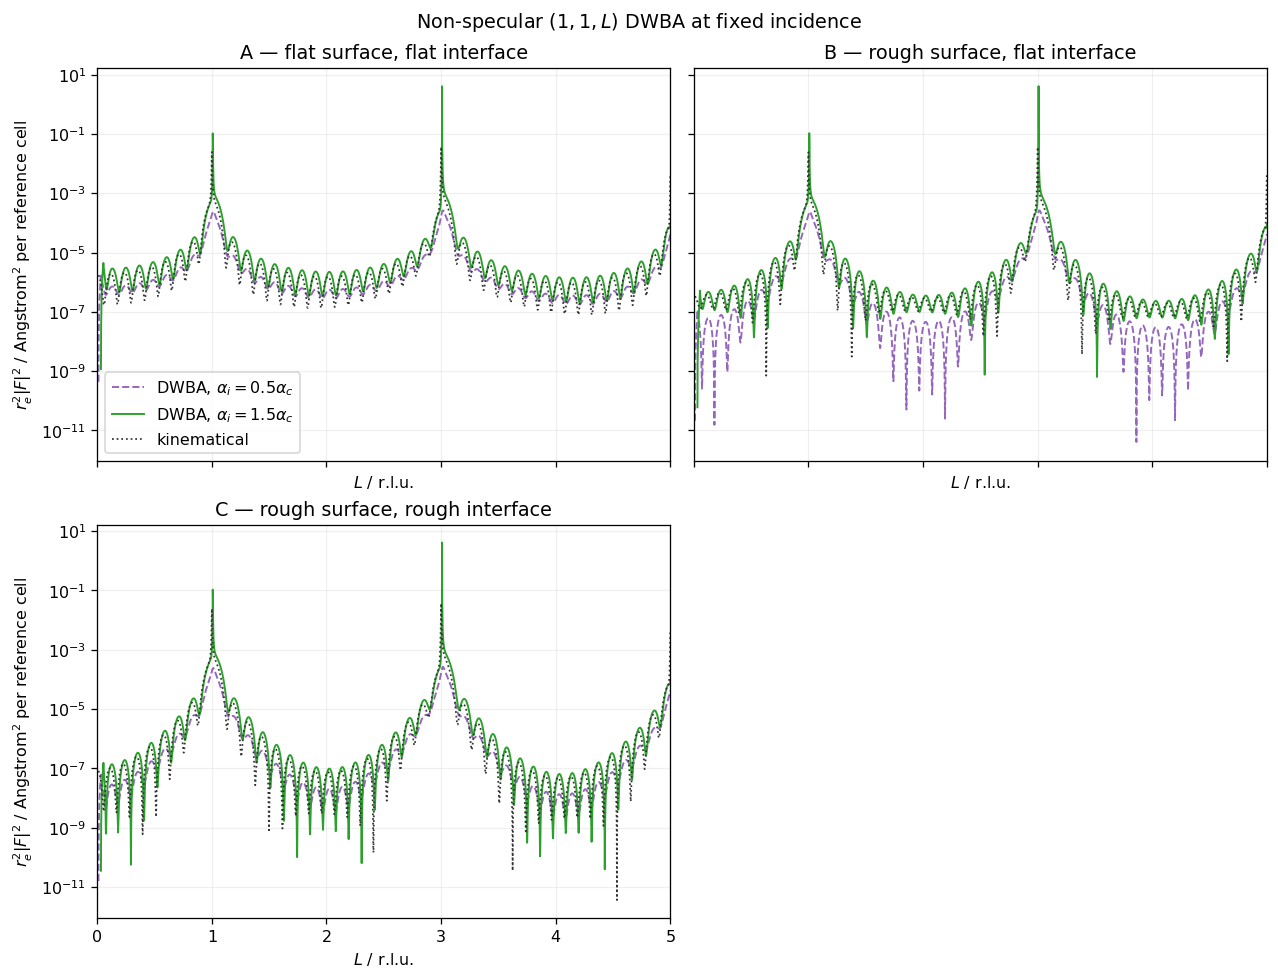

In [10]:
figure, axes = _two_column_axes(len(non_specular_ctr), row_height=4.2)
styles = {0.5: ("C4", "--"), 1.5: ("C2", "-")}
for axis, (label, scans) in zip(axes, non_specular_ctr.items()):
    for factor, scan in scans.items():
        color, linestyle = styles[factor]
        axis.semilogy(
            scan["L"], scan["dwba"], color=color,
            ls=linestyle, lw=1.2,
            label=rf"DWBA, $\alpha_i={factor:g}\alpha_c$",
        )
    kinematic = scans[0.5]
    axis.semilogy(
        kinematic["L"], kinematic["kinematic"],
        color="0.2", ls=":", lw=1.1,
        label="kinematical",
    )
    axis.set_title(label)
    axis.set_xlabel(r"$L$ / r.l.u.")
    axis.set_xlim(0.0, 5.0)
    axis.grid(alpha=0.18, which="both")

for axis in axes[len(non_specular_ctr):]:
    axis.set_visible(False)
for axis in axes[:len(non_specular_ctr):2]:
    axis.set_ylabel(
        r"$r_e^2|F|^2$ / Angstrom$^2$ per reference cell"
    )
axes[0].legend(loc="lower left")
figure.suptitle(r"Non-specular $(1,1,L)$ DWBA at fixed incidence")

## Reading the diagnostics

- Surface and interface roughness alter both the layered reference $n_0$ and
  the atomistic contrast $\Delta n$; the first figure shows that bookkeeping
  explicitly and verifies $n=n_0+\Delta n$ numerically.
- Near $\alpha_c$, $r_0$ supplies the Fresnel edge while $\Delta r$ carries
  the atomic correction.  Their amplitudes must be added before squaring;
  the kinematical curve shows why the Born result cannot replace the
  optical reference below the critical edge.
- Along the extended specular rod, the Fresnel and CTR pieces remain one
  coherent observable.  Close to Bragg poles, first-order DWBA is not a full
  dynamical diffraction theory.
- On $(1,1,L)$, the planar reference vanishes identically.  The two incidence
  angles therefore probe changes in the distorted fields and four-channel
  interference, not an additive Fresnel background.  The shared
  kinematical curve provides the undistorted comparison.
